<a href="https://colab.research.google.com/github/akshita2736/DocScanner/blob/main/DocScanner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# func to load image
def load_image(path):
  image = cv2.imread(path)
  if image is None:
    raise FileNotFoundError(f"Could not open image: {path}")
  return image

In [ ]:
# resize image (size smaller) for detection purpose
def resize_image(image, height=700):
  ratio = image.shape[0] / height
  width = int(image.shape[1] * (height/image.shape[0]))
  resized = cv2.resize(image, (width,height))
  return resized, ratio

# image.shape[0] --> height
# image.shape[1] --> width
# ratio --> scaling factor

In [ ]:
def preprocess(image):
  #convert to grayscale
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

  # gaussian filter
  blurred = cv2.GaussianBlur(gray, (5,5), 0)

  # canny edge detection (rapid intensity change)
  edges = cv2.Canny(blurred, 50, 150)
  kernel = np.ones((3,3), np.uint8)

  # Morphology (dilation --> thicken edges & fill broken edges for better scan)
  # intentionally convert thin edges to thick here (using dilation)
  edges = cv2.dilate(edges, kernel, iterations=1)
  return edges

In [ ]:
def find_document_contour(edges):
  contours, _= cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

  # contours, _ --> only gives contour, not hierarchy
  # contours --> outline/boundary
  # RETR_LIST --> retrieval list (retrieve all possible boundaries)
  # CHAIN_APPROX_SIMPLE --> unnecessary points removal (uses lesser memory --> saves space)
  # eg: SQUARE (min. 4 points needed only)

  contours = sorted(contours, key = cv2.contourArea, reverse = True)
  # returns list sorted on the basis of contourArea
  # reverse = True --> descending order of boundary area

  for contour in contours[0:10]:
    perimeter = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.02*perimeter, True)
    # approxPolyDP --> returns the corners of the polygon
    # True --> closed polygon
    # converts complex contour into a simple polygon
    # 0.02*perimeter --> only 2% error allowed in perimeter calculation

    if len(approx) == 4:
      return approx
  return None;   # no such 4 points found using which a contour can be made

In [ ]:
# to see which corner point is top-left, top-right, bottom-left, bottom-right

def order_corner(pts):
  pts = pts.reshape(4,2).astype(np.float32)
  ordered = np.zeros((4,2), dtype=np.float32)
  # (4,2) --> 4 points, 2 coordinates

  s= pts.sum(axis=1)
  ordered[0] = pts[np.argmin(s)]  # top-left
  ordered[2] = pts[np.argmax(s)]  # bottom-right

  diff = np.diff(pts, axis=1)
  ordered[1] = pts[np.argmin(diff)]  # top-right
  ordered[3] = pts[np.argmax(diff)]  # bottom-left

  return ordered

In [ ]:
# WARP --> to bend, twist, or distort out of shape
# to turn (transform) to the correct shape (eg: parallelogram to rectangle)
# perspective transform
# I have 4 corner points --> calculate height and width using distance formula

def warp_document(image, corners):
  tl, tr, br, bl = corners

  W = int(max(np.linalg.norm(tr-tl), np.linalg.norm(br-bl)))
  H = int(max(np.linalg.norm(bl-tl), np.linalg.norm(br-tr)))

  dest = np.array([
      [0,0],
      [W-1, 0],
      [W-1, H-1],
      [0, H-1]
  ], dtype = np.float32)
  # array of coordinates of corners

  # perspective matrix --> mapping btw source & destination
  M = cv2.getPerspectiveTransform(corners, dest)
  return cv2.warpPerspective(image, M, (W,H))

In [ ]:
def make_scan_look(warped):
  # CLAHE --> fix uneven lighting
  # DENOISE
  # OTSU --> automatically find the best threshold to make it B&W

  gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

  # deNoise --> removes noise while preserving edges
  # fast non local denoising
  enhanced = clahe.apply(gray)
  enhanced = cv2.fastNlMeansDenoising(enhanced, None, 10, 7, 21)

  # threshold
  #_, scanned = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
  scanned = cv2.adaptiveThreshold(
    enhanced,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)
  return scanned

In [ ]:
def show_results(original, edges, detected, warped, scan):
  orig_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
  detected_rgb = cv2.cvtColor(detected, cv2.COLOR_BGR2RGB)
  warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

  fig, axes = plt.subplots(1,5, figsize=(20,5))
  fig.suptitle("Doc scanner", fontsize=14, fontweight = "bold")

  steps = [
      (orig_rgb, "Step1: original"),
      (edges, "Step2: edges"),
      (detected_rgb, "Step3: detected rgb"),
      (warped_rgb, "Step4: warped"),
      (scan, "Step5: final scan")
  ]
  for ax, (img, title) in zip(axes, steps):
    ax.imshow(img, cmap="gray" if len(img.shape)==2 else None)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

  # beautiful representation (corrects padding etc.)
  plt.tight_layout(rect=[0, 0, 1, 0.95])
  plt.savefig("scanner_results.jpg", dpi=150, bbox_inches="tight")
  # saves the scanned file
  plt.show()
  print("done saved as docScanner.jpg")

In [ ]:
# creating the entire pipeline
def scan_document(image_path):
  print(f"\n Scanning: {image_path}")
  print("--" * 40)

  print("1. Loading the image...")
  original = load_image(image_path)
  print(f" Size: {original.shape[1]} * {original.shape[0]} px")

  print("2. Resizing the image for detection: ")
  small, ratio = resize_image(original, height=700)

  print("3. preprocessing: edge detection")
  edges = preprocess(small)

  # find the outline / boundary
  print("4. find document outline: ")
  contour = find_document_contour(edges)

  if contour is None:
    print("no such 4 points found using which a contour can be made")
    print("document on contrasting background")
    print("all four corners should be visible")
    print("improve lighting, avoid shadows")

  print("found the four cornered outline")

  detected = small.copy()
  cv2.drawContours(detected, [contour], -1, (0, 255, 0), 3)
  for point in contour.reshape(4,2):
    cv2.circle(detected, tuple(point.astype(int)), 8, (0,0,255), -1)

  print("5. Applying perspective correction...")
  # scaling corners back to original resolution
  corners = order_corner(contour*ratio)
  warped = warp_document(original, corners)

  # create a scan effect
  print("6. apply scan effect: CLAHE, Otsu thresholding")
  scan = make_scan_look(warped)

  cv2.imwrite("final_scan.jpg", scan)
  print("we have saved your file")

  # show
  print("7. showing results: ")
  show_results(original, edges, detected, warped, scan)



 Scanning: docScanner.jpg
--------------------------------------------------------------------------------
1. Loading the image...
 Size: 804 * 1038 px
2. Resizing the image for detection: 
3. preprocessing: edge detection
4. find document outline: 
found the four cornered outline
5. Applying perspective correction...
6. apply scan effect: CLAHE, Otsu thresholding
we have saved your file
7. showing results: 


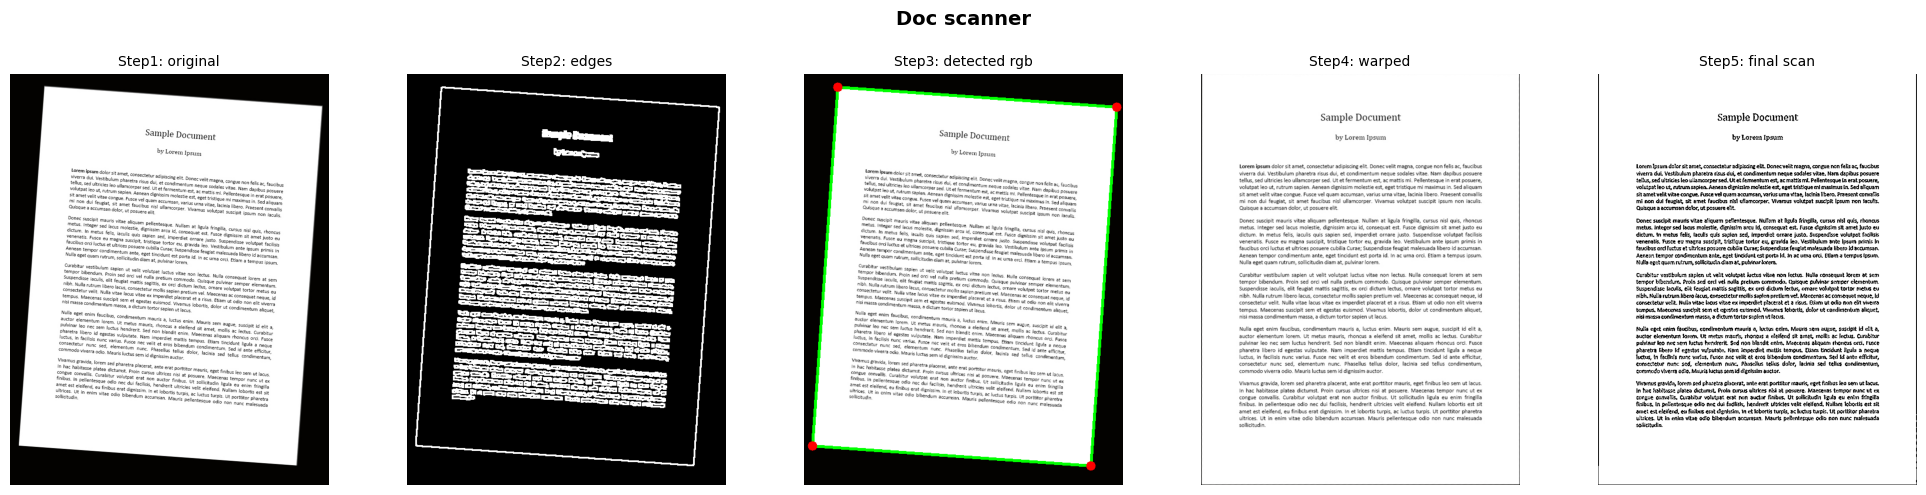

done saved as docScanner.jpg


In [ ]:
if __name__ == "__main__":
  IMAGE_PATH = "docScanner.jpg"
  scan_document(IMAGE_PATH)

In [ ]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'drive', '.ipynb_checkpoints', 'final_scan.jpg', 'docScanner.jpg', 'scanner_results.jpg', 'sample_data']
